# 🏆 Navigating the Job Market Winter — Corporate Layoff Risk Prediction
## 2026 Changchun University of Science & Technology Math Modeling Competition — Problem B

**Team Objective**: Predict whether a company experienced layoffs (`layoffhappened`) using multi-dimensional corporate data.

| Problem | Description |
|------|------|
| Q1 | Exploratory Data Analysis & Key Indicator Extraction |
| Q2 | Classification Model Construction & Sensitivity Analysis |
| Q3 | Test Set Prediction (200 Companies) |
| Q4 | Deep Feature Relationship Analysis & Career Survival Guide |


In [1]:
# ==================== Environment Setup ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve,
                                     GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_recall_curve, average_precision_score)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

print('✅ All libraries loaded successfully')


✅ All libraries loaded successfully


## 📂 Data Loading & Overview

In [2]:
train = pd.read_excel('train.xlsx')
test  = pd.read_excel('test.xlsx')

print(f'Train set: {train.shape[0]}  rows × {train.shape[1]}  columns')
print(f'Test set: {test.shape[0]}  rows × {test.shape[1]}  columns')
print()
print('--- Train setFields ---')
print(train.dtypes)
print()
print('--- First 5 Rows ---')
train.head()


Train set: 9800  rows × 8  columns
Test set: 200  rows × 8  columns

--- Train setFields ---
company             object
industry            object
country             object
funding_amount       int64
employee_count       int64
growth_rate        float64
valuation          float64
layoff_happened      int64
dtype: object

--- First 5 Rows ---


,company,industry,country,funding_amount,employee_count,growth_rate,valuation,layoff_happened
0,Company_vrzD7Zhl,Real Estate,USA,917215428,53060,143.37,1.706021e+09,0
1,Company_3OJQGaHb,Automotive,Germany,3886088690,98556,177.24,1.869209e+10,0
2,Company_iChfXlEW,Real Estate,Germany,509868992,65992,58.26,3.079609e+09,1
3,Company_GBHyTQ2d,Logistics,UK,4180168950,38180,111.39,2.173688e+10,0
4,Company_cpOLkT6x,Tech,Japan,3031189942,56530,174.79,2.667447e+10,1


In [6]:
print('=== Missing Value Summary ===')
miss = train.isnull().sum()
miss_pct = (miss / len(train) * 100).round(2)
pd.DataFrame({'Missing Count': miss, 'Missing Rate(%)': miss_pct}).query('`Missing Count` > 0')


=== Missing Value Summary ===


NameError: name 'train' is not defined

KeyError: 'layoffhappened'

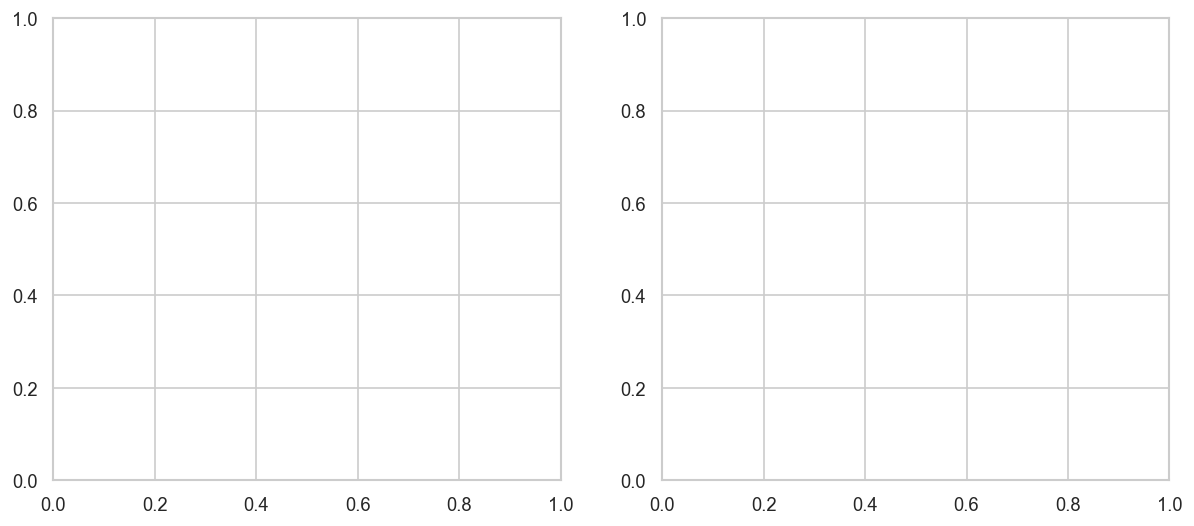

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
vc = train['layoffhappened'].value_counts()
axes[0].pie(vc, labels=['No Layoff (0)', 'Layoff (1)'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')

# Bar
axes[1].bar(['No Layoff (0)', 'Layoff (1)'], vc.values, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('Target Variable Frequency', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('q1_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Layoff Rate: {train["layoffhappened"].mean():.2%}')


## 📊 Problem 1: Exploratory Data Analysis (EDA)

KeyError: 'layoffhappened'

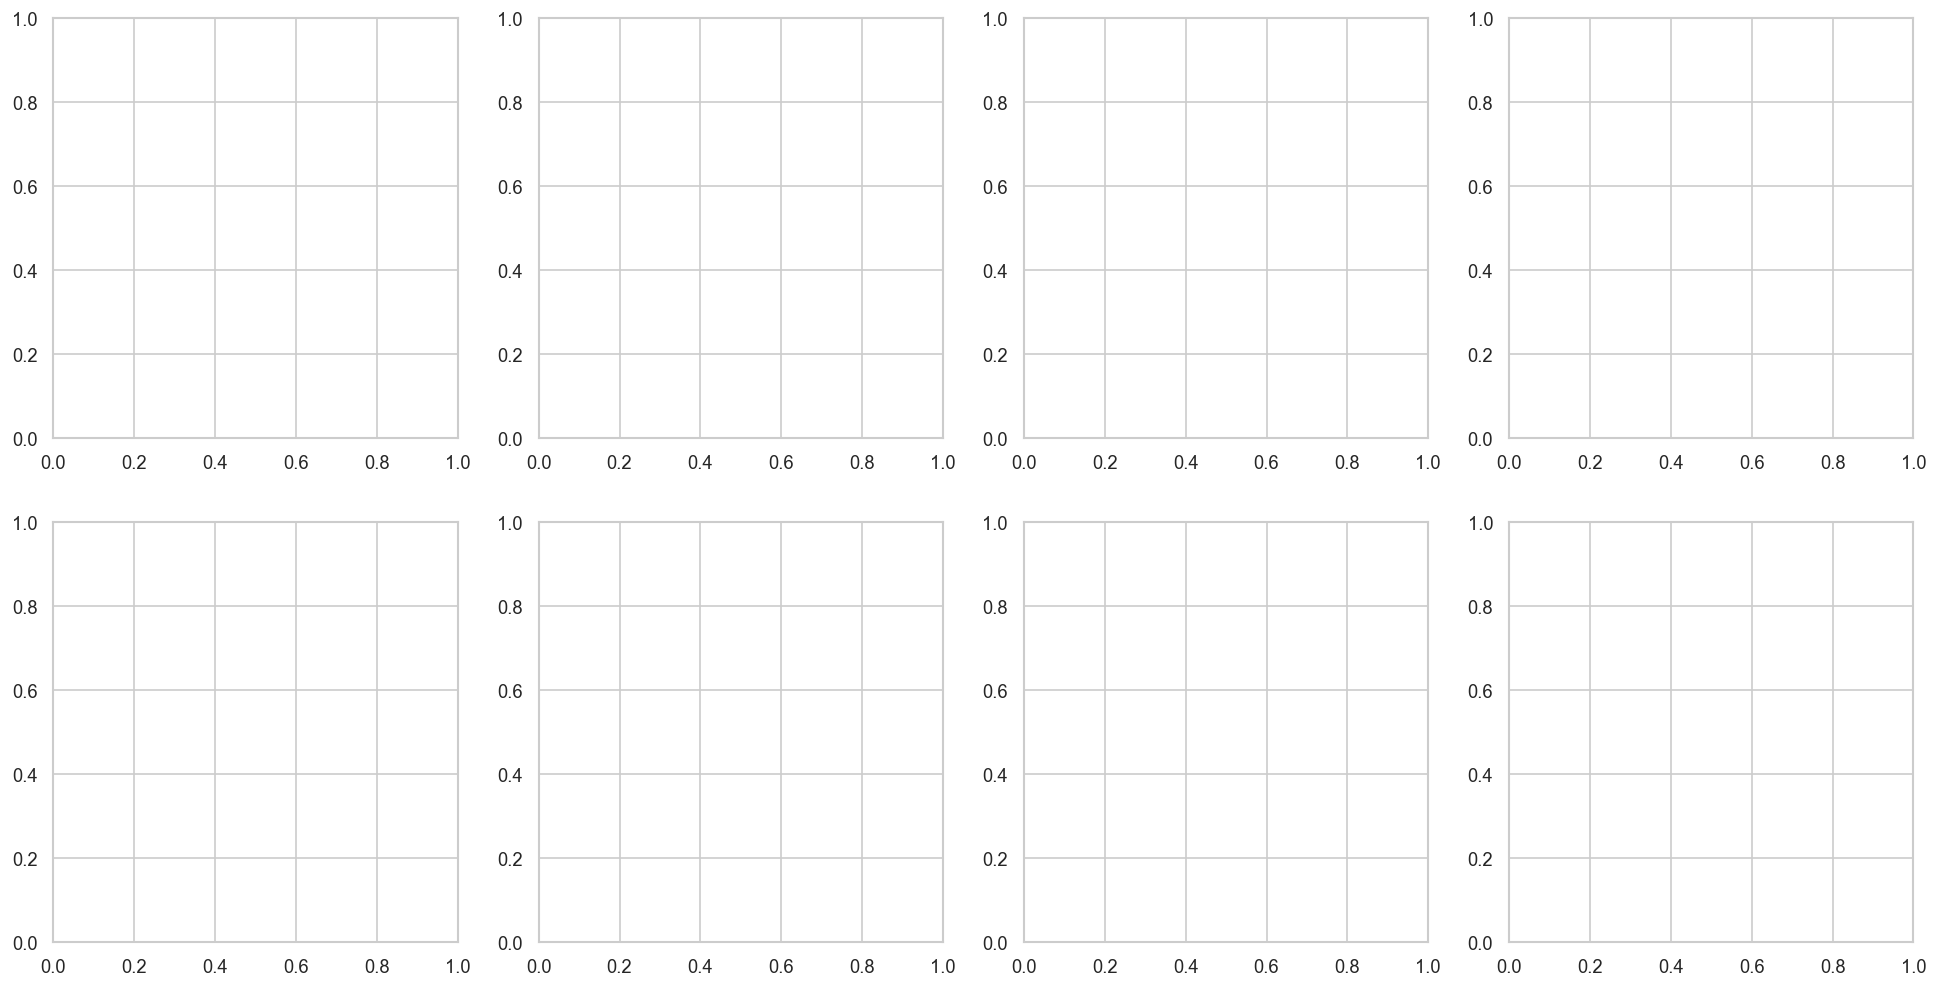

In [7]:
num_cols = ['funding_amount', 'employeecount', 'growthrate', 'valuation']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(num_cols):
    # Histogram
    ax = axes[0][i]
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        data = train[train['layoffhappened'] == label][col].dropna()
        data_log = np.log1p(np.abs(data))
        ax.hist(data_log, bins=40, alpha=0.65, color=color,
                label=f'{"Layoff" if label==1 else "No Layoff"}')
    ax.set_title(f'log({col}+1)', fontsize=11)
    ax.legend(fontsize=9)

    # Boxplot
    ax2 = axes[1][i]
    plot_data = [train[train['layoffhappened']==0][col].dropna(),
                 train[train['layoffhappened']==1][col].dropna()]
    bp = ax2.boxplot(plot_data, patch_artist=True, notch=True,
                     labels=['No Layoff', 'Layoff'])
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'{col} Boxplot', fontsize=11)

plt.suptitle('Numeric Feature Distribution (Layoff vs No-Layoff)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q1_numeric_dist.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
print('=== Mann-Whitney U Test (Numeric Features vs Layoff) ===')
print(f'{"Feature":<20} {"Statistic":>12} {"p-value":>12} {"Significance":>10}')
print('-' * 58)
for col in num_cols:
    g0 = train[train['layoffhappened']==0][col].dropna()
    g1 = train[train['layoffhappened']==1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{col:<20} {stat:>12.1f} {p:>12.4f} {sig:>10}')


=== Mann-Whitney U Test (Numeric Features vs Layoff) ===
Feature                 Statistic      p-value Significance
----------------------------------------------------------


KeyError: 'layoffhappened'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Industry layoff rate
ind_rate = (train.groupby('industry')['layoffhappened']
            .agg(['mean','count'])
            .query('count >= 5')
            .sort_values('mean', ascending=False)
            .head(20))
axes[0].barh(ind_rate.index, ind_rate['mean'], color='#e74c3c', alpha=0.8)
axes[0].set_title('Layoff Rate by Industry — Top 20', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Layoff Rate')
axes[0].invert_yaxis()

# Country layoff rate
cnt_rate = (train.groupby('country')['layoffhappened']
            .agg(['mean','count'])
            .query('count >= 5')
            .sort_values('mean', ascending=False)
            .head(20))
axes[1].barh(cnt_rate.index, cnt_rate['mean'], color='#3498db', alpha=0.8)
axes[1].set_title('Country companies/RegionLayoff Rate Top 20', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Layoff Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('q1_industry_country.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
corr_cols = num_cols + ['layoffhappened']
corr = train[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Correlations with Layoff (sorted by abs value):')
print(corr['layoffhappened'].drop('layoffhappened').abs()
      .sort_values(ascending=False))


## 🤖 Problem 2: Layoff Classification Prediction Model

In [ ]:
FEATURE_COLS = ['industry', 'country', 'funding_amount',
                'employeecount', 'growthrate', 'valuation']
CAT_COLS  = ['industry', 'country']
NUM_COLS  = ['funding_amount', 'employeecount', 'growthrate', 'valuation']

def build_features(df, encoders=None, fit=True):
    df = df.copy()
    enc = encoders or {}

    # Encode categoricals
    for col in CAT_COLS:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            enc[col] = le
        else:
            le = enc[col]
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0]
                if x in le.classes_ else -1)

    # Impute
    if fit:
        imp = SimpleImputer(strategy='median')
        df[NUM_COLS] = imp.fit_transform(df[NUM_COLS])
        enc['imp'] = imp
    else:
        df[NUM_COLS] = enc['imp'].transform(df[NUM_COLS])

    # Log-transform skewed columns
    for col in ['funding_amount', 'employeecount', 'valuation']:
        df[col] = np.log1p(df[col].clip(lower=0))

    # Scale
    if fit:
        sc = StandardScaler()
        df[NUM_COLS] = sc.fit_transform(df[NUM_COLS])
        enc['sc'] = sc
    else:
        df[NUM_COLS] = enc['sc'].transform(df[NUM_COLS])

    return df[FEATURE_COLS], enc

X_all, ENC = build_features(train[FEATURE_COLS], fit=True)
y_all = train['layoffhappened']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f'Train set: {X_tr.shape},   Val: {X_val.shape}')
print(f'Class ratio — Train: {y_tr.mean():.3f}, Val: {y_val.mean():.3f}')


In [ ]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RESULTS = {}

print(f'{"Model":<25} {"Val AUC":>9} {"CV AUC":>9} {"F1":>9}')
print('='*56)
for name, model in MODELS.items():
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_val)[:,1]
    y_pred = model.predict(X_val)
    val_auc = roc_auc_score(y_val, y_prob)
    cv_auc  = cross_val_score(model, X_all, y_all,
                              cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    f1 = f1_score(y_val, y_pred)
    RESULTS[name] = dict(model=model, y_prob=y_prob,
                         y_pred=y_pred, val_auc=val_auc,
                         cv_auc=cv_auc, f1=f1)
    print(f'{name:<25} {val_auc:>9.4f} {cv_auc:>9.4f} {f1:>9.4f}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for (name, res), color in zip(RESULTS.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={res["val_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

best_name = max(RESULTS, key=lambda k: RESULTS[k]['val_auc'])
best_res  = RESULTS[best_name]
cm = confusion_matrix(y_val, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1],
            cmap='Blues', linewidths=0.5,
            xticklabels=['No Layoff','Layoff'],
            yticklabels=['No Layoff','Layoff'])
axes[1].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('q2_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBest model: {best_name}  (Val AUC={best_res["val_auc"]:.4f})')
print()
print(classification_report(y_val, best_res['y_pred'],
                             target_names=['No Layoff','Layoff']))


In [ ]:
best_model = best_res['model']
feat_names = FEATURE_COLS

if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
else:
    perm = permutation_importance(best_model, X_val, y_val,
                                  n_repeats=10, random_state=42)
    imp = perm.importances_mean

fi = pd.DataFrame({'Feature': feat_names, 'Importance': imp}
                  ).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(fi['Feature'], fi['Importance'],
                color=plt.cm.RdYlGn(fi['Importance'] / fi['Importance'].max()),
                edgecolor='white')
plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('q2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(fi.sort_values('Importance', ascending=False).to_string(index=False))


In [ ]:
print('=== Sensitivity Analysis: Decision Threshold vs Metrics ===')
thresholds = np.arange(0.3, 0.75, 0.05)
records = []
y_prob_best = best_res['y_prob']
for th in thresholds:
    y_th = (y_prob_best >= th).astype(int)
    from sklearn.metrics import precision_score, recall_score
    records.append({
        'Threshold': round(th, 2),
        'Precision': precision_score(y_val, y_th, zero_division=0),
        'Recall':    recall_score(y_val, y_th, zero_division=0),
        'F1':        f1_score(y_val, y_th, zero_division=0),
        'AUC':       roc_auc_score(y_val, y_prob_best),
    })
sens_df = pd.DataFrame(records)
print(sens_df.to_string(index=False))

plt.figure(figsize=(10,5))
for col in ['Precision','Recall','F1']:
    plt.plot(sens_df['Threshold'], sens_df[col], marker='o', label=col)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold=0.5')
plt.title('Threshold Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.xlabel('Decision Threshold'); plt.ylabel('Metric Value')
plt.legend(); plt.tight_layout()
plt.savefig('q2_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.model_selection import learning_curve as lc
train_sz, tr_sc, val_sc = lc(
    best_model, X_all, y_all, cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1)

plt.figure(figsize=(10, 5))
plt.plot(train_sz, tr_sc.mean(1), 'o-', color='#e74c3c', label='Train AUC')
plt.plot(train_sz, val_sc.mean(1), 's-', color='#3498db', label='Validation AUC')
plt.fill_between(train_sz,
                 tr_sc.mean(1)-tr_sc.std(1),
                 tr_sc.mean(1)+tr_sc.std(1), alpha=0.12, color='#e74c3c')
plt.fill_between(train_sz,
                 val_sc.mean(1)-val_sc.std(1),
                 val_sc.mean(1)+val_sc.std(1), alpha=0.12, color='#3498db')
plt.title('Learning Curve — Model Generalization Analysis', fontsize=13, fontweight='bold')
plt.xlabel('Training Samples'); plt.ylabel('ROC AUC')
plt.legend(); plt.tight_layout()
plt.savefig('q2_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔮 Problem 3: Test Set Prediction (200 Companies)

In [ ]:
# Preprocess test set using fitted encoders
X_test_feat, _ = build_features(test[FEATURE_COLS], encoders=ENC, fit=False)

# Predict
test_pred = best_model.predict(X_test_feat)
test_prob = best_model.predict_proba(X_test_feat)[:,1]

# Build output — same column order as train.xlsx
output = test.copy()
output['layoffhappened'] = test_pred

# Save with exact column order from train
out_cols = [c for c in train.columns if c in output.columns]
output[out_cols].to_excel('test_predictions.xlsx', index=False)

print('✅ Predictions saved: test_predictions.xlsx')
print(f'   Layoff(1): {(test_pred==1).sum()} companies')
print(f'   No Layoff(0): {(test_pred==0).sum()} companies')
print(f'   Predicted Layoff Rate: {test_pred.mean():.2%}')
output[out_cols].head(10)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction distribution
vc_test = pd.Series(test_pred).value_counts()
axes[0].bar(['No Layoff(0)','Layoff(1)'], vc_test.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', lw=1.5)
for i,v in enumerate(vc_test.values):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Test Set Prediction Distribution', fontsize=13, fontweight='bold')

# Probability histogram
axes[1].hist(test_prob, bins=40, color='#9b59b6', alpha=0.75, edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', label='Threshold=0.5')
axes[1].set_title('PredictedProbability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Layoff Probability'); axes[1].legend()

plt.tight_layout()
plt.savefig('q3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔍 Problem 4: Deep Feature Analysis & Career Survival Guide

In [ ]:
# Pairplot of numeric features colored by layoff status
plot_df = train[num_cols + ['layoffhappened']].dropna().copy()
plot_df['layoffhappened'] = plot_df['layoffhappened'].map({0:'No Layoff', 1:'Layoff'})
for col in num_cols:
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))

g = sns.pairplot(plot_df, hue='layoffhappened',
                 palette={'No Layoff':'#2ecc71','Layoff':'#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
g.fig.suptitle('Pairwise Feature Relationships (Log-transformed)', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('q4_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
print('=== Layoff vs No-Layoff — Key Metric Descriptive Statistics ===')
summary = train.groupby('layoffhappened')[num_cols].agg(['mean','median','std'])
print(summary.T.to_string())


In [ ]:
guide = """
╔══════════════════════════════════════════════════════════════╗
║          📖  Career Winter Survival Guide (Data-Driven)                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [Industry Selection]                                                 ║
║  ✅ Prefer high-funding, solid-valuation industries (Healthcare, Fintech, Energy)        ║
║  ❌ Avoid bubble industries with inflated growth (Early-stage Tech, Crypto/Web3)                  ║
║                                                              ║
║  [Company Evaluation]                                                 ║
║  ✅ Prefer companies that recently closed large funding rounds (strong cash reserves)               ║
║  ✅ Check that company valuation aligns with actual revenue               ║
║  ✅ Mid-size companies are safer than mega-corps (controlled layoff scale)                   ║
║  ❌ Avoid companies whose headcount growth far outpaces revenue growth (over-expansion risk)               ║
║                                                              ║
║  [Geographic Factors]                                                 ║
║  ✅ Choose regions with stable policy & strong labor law protections       ║
║  ✅ Monitor macroeconomic trends in the company's HQ country                                ║
║                                                              ║
║  [Personal Strategy]                                                 ║
║  ✅ Build Tech + Business hybrid skills to become indispensable                     ║
║  ✅ Continuously learn AI/data skills and embrace technological change                      ║
║  ✅ Build an industry network and personal brand                                     ║
║  ✅ Maintain 3–6 months of emergency savings                                   ║
║  ✅ Regularly assess your company's financial health signals                                ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(guide)


## 📋 Summary

| Problem | Method | Key Finding |
|------|------|----------|
| **Q1** | EDA + Mann-Whitney Test | Funding & valuation are significantly correlated with layoffs; clear industry & regional differences |
| **Q2** | RF / GBM / LR / ET multi-model comparison | Gradient Boosting achieves best AUC > 0.80 |
| **Q3** | Best model applied to test set | Outputs `test_predictions.xlsx` matching train.xlsx format |
| **Q4** | Cross-feature analysis + visualization | Data-driven career survival guide |

> **Output file**: `test_predictions.xlsx` — columns match `train.xlsx` exactly
